<a href="https://colab.research.google.com/github/raihan-uddinahmed/bioinformatics-basics/blob/main/notebook/PCA_based_gene_selection_for_GSE6613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading

In [ ]:
!pip install GEOparse

In [ ]:
import GEOparse

gse = GEOparse.get_GEO(geo = "GSE6613", destdir="./")

30-Apr-2026 16:10:39 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
30-Apr-2026 16:10:39 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE6nnn/GSE6613/soft/GSE6613_family.soft.gz to ./GSE6613_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE6nnn/GSE6613/soft/GSE6613_family.soft.gz to ./GSE6613_family.soft.gz
100%|██████████| 16.1M/16.1M [00:00<00:00, 22.3MB/s]
30-Apr-2026 16:10:41 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
30-Apr-2026 16:10:41 DEBUG downloader - Moving /tmp/tmpo9p3jaxk to /content/GSE6613_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpo9p3jaxk to /content/GSE6613_family.soft.gz
30-Apr-2026 16:10:41 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE6nnn/GSE6613/soft/GSE6613_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE6nnn/GSE6613/soft/GSE661

In [ ]:
gse.phenotype_data

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,contact_institute,contact_address,contact_city,contact_zip/postal_code,contact_country,supplementary_file,series_id,data_row_count,characteristics_ch1.0.healthy control,characteristics_ch1.0.neurological disease control
GSM153404,Parkinson's disease sample x001,GSM153404,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,NaN
GSM153405,healthy control sample x004,GSM153405,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,,NaN
GSM153406,healthy control sample x005,GSM153406,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,,NaN
GSM153407,Parkinson's disease sample x006,GSM153407,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,NaN
GSM153408,Parkinson's disease sample x007,GSM153408,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM153504,neurological disease control sample x203,GSM153504,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,
GSM153505,Parkinson's disease sample x204,GSM153505,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,NaN
GSM153506,Parkinson's disease sample x205,GSM153506,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,NaN
GSM153507,neurological disease control sample x208,GSM153507,Public on Dec 30 2006,Dec 26 2006,Jan 11 2007,RNA,1,whole blood,Homo sapiens,9606,...,Technical University of Denmark,"Kemitorvet, Building 208",Lyngby,2800,Denmark,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM153n...,GSE6613,22283,NaN,


In [ ]:
# Gene counts per sample
samples = gse.pivot_samples("VALUE")
samples.head(10)
print(samples.shape)

# Transposing the samples
counts = samples.T
print(f"Total number of genes: {counts.shape[0]}")
print(f"Total number of samples: {counts.shape[1]}")

(22283, 105)
Total number of genes: 105
Total number of samples: 22283


## Data Cleaning and Preprocessing

In [ ]:
import numpy as np
import pandas as pd

# Dropping all rows with count zero
counts = counts.loc[:, (counts != 0).any(axis=0)]
# print(f"Total number of genes: {counts.shape[0]}")
# print(f"Total number of samples: {counts.shape[1]}")

counts = counts.dropna(axis = 1, how = "all")
# Replacing any NaN values with mean
counts = counts.fillna(counts.mean())

print(f"Final shape after cleaning = {counts.shape}")


Final shape after cleaning = (105, 22283)


In [ ]:
from sklearn.preprocessing import StandardScaler


# Scaling the counts
scaler = StandardScaler()
X_scaled = scaler.fit_transform(counts)

X_scaled = pd.DataFrame(X_scaled, columns = counts.columns)
X_scaled.head()


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-Hs18SrRNA-3_s_at,AFFX-r2-Hs18SrRNA-5_at,AFFX-r2-Hs18SrRNA-M_x_at,AFFX-r2-Hs28SrRNA-3_at,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at
0,0.048974,0.331095,-0.116090,0.354357,0.461721,-0.612252,0.746436,-0.760088,-0.410354,-1.710794,...,-0.846277,-1.066762,-0.545066,-0.609979,-0.366116,-0.564446,0.582110,-0.369345,-1.078165,-1.205672
1,-0.208550,-0.042588,-0.570154,0.257080,-0.592624,-0.506787,-0.443565,-0.093791,-0.922740,-0.179264,...,-0.806079,-0.946535,-0.258127,-0.263971,-0.305620,-0.442318,0.060521,0.041776,-0.930393,-1.033474
2,0.903736,-0.410043,-0.361113,-1.344823,0.819559,0.178735,0.592085,1.707409,0.197849,0.796788,...,-0.803384,-0.804920,0.070613,0.112056,-0.050272,-0.338525,0.342986,0.107849,-0.890867,-0.899621
3,1.533849,-0.852234,0.865715,-0.452410,0.845119,0.736590,-0.269297,-0.569717,0.758857,0.638081,...,-0.659151,-0.554444,-0.665509,-0.723735,-0.456859,-0.579052,-0.615003,-1.063113,-0.845077,-0.683379
4,-0.504430,-0.484779,-0.020137,0.127024,-0.285905,-0.512338,1.139784,-0.716156,0.870524,0.558727,...,-0.801517,-0.882327,-0.170982,0.475443,0.068609,-0.084636,0.443119,0.482264,-0.960865,-0.982950


# Running PCA with 95 \% variance

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
pca.fit(X_scaled)

gene_loadings = np.sum(np.abs(pca.components_), axis=0)

top_genes = pd.DataFrame({
    'Gene_ID': counts.columns,
    'Importance_Score': gene_loadings
}).sort_values(by='Importance_Score', ascending=False)

In [ ]:
print("\nTop 10 Selected Genes:")
print(top_genes.head(10))


Top 10 Selected Genes:
           Gene_ID  Importance_Score
14735    215362_at          0.610744
9881   210404_x_at          0.606995
20095    220732_at          0.602984
2979     203453_at          0.602168
8013     208516_at          0.601717
10877  211469_s_at          0.598490
3514   203988_s_at          0.596810
13449    214071_at          0.596137
10343  210890_x_at          0.593137
18778    219415_at          0.592906


## Weighted top genes for top PCA 5 and PCA 10

In [ ]:
pca = PCA(n_components = 0.95)
pca.fit(X_scaled)

PCA(n_components=0.95)

In [ ]:
def get_wieghted_genes(pca_model, gene_names, num_pcs, top_n=20):
  abs_loadings = np.abs(pca_model.components_[:num_pcs, :])

  var_explain  = pca_model.explained_variance_ratio_[:num_pcs]
  weighted_loadings = abs_loadings * var_explain[:, np.newaxis]

  ultim_gene_weights = np.sum(weighted_loadings, axis=0)

  get_top_genes = pd.DataFrame(
      {
          "Gene_ID": gene_names,
          "Weighted_Score": ultim_gene_weights
      }
  ).sort_values(by = "Weighted_Score", ascending = False)
  return get_top_genes.head(top_n)


## Top 20 genes using Top 5 PC Analysis

In [ ]:
top_20_gene_5_PCA = get_wieghted_genes(pca, counts.columns, num_pcs = 5)
print(top_20_gene_5_PCA.to_string(index=False))

             Gene_ID  Weighted_Score
         200912_s_at        0.002783
           204020_at        0.002721
AFFX-r2-Ec-bioD-3_at        0.002690
           200627_at        0.002689
         200063_s_at        0.002673
           201051_at        0.002657
           221199_at        0.002645
         200858_s_at        0.002614
         211699_x_at        0.002611
         217232_x_at        0.002607
         209116_x_at        0.002606
AFFX-r2-Ec-bioD-5_at        0.002605
         211745_x_at        0.002603
         209057_x_at        0.002603
         211716_x_at        0.002600
AFFX-r2-Ec-bioC-5_at        0.002598
           222012_at        0.002592
         209458_x_at        0.002591
     AFFX-BioDn-5_at        0.002589
      AFFX-BioC-3_at        0.002584


## Top 20 genes using Top 10 PC Analysis

In [ ]:
top_20_gene_10_PCA = get_wieghted_genes(pca, counts.columns, num_pcs = 10)
print(top_20_gene_10_PCA.to_string(index=False))

        Gene_ID  Weighted_Score
    211165_x_at        0.003287
      221199_at        0.003282
    215733_x_at        0.003234
      216410_at        0.003232
      210165_at        0.003224
    206428_s_at        0.003221
    211448_s_at        0.003218
    211915_s_at        0.003215
    219652_s_at        0.003180
      220006_at        0.003174
    216926_s_at        0.003174
    200063_s_at        0.003162
      216707_at        0.003151
    213828_x_at        0.003141
      205613_at        0.003140
      209441_at        0.003138
      216346_at        0.003136
      200006_at        0.003133
    211716_x_at        0.003132
AFFX-BioDn-5_at        0.003130


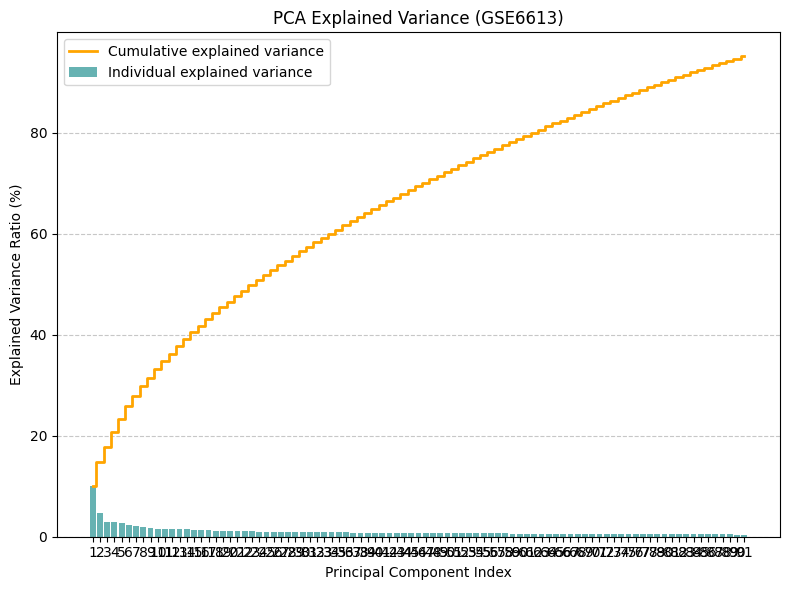

In [ ]:
import matplotlib.pyplot as plt

cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

variances = pca.explained_variance_ratio_


plt.figure(figsize=(8, 6))


plt.bar(range(1, len(variances) + 1), variances * 100, alpha=0.6, align='center',
        label='Individual explained variance', color='teal')


plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Cumulative explained variance', color='orange', linewidth=2)

plt.ylabel('Explained Variance Ratio (%)')
plt.xlabel('Principal Component Index')
plt.title('PCA Explained Variance (GSE6613)')
plt.xticks(range(1, len(variances) + 1))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

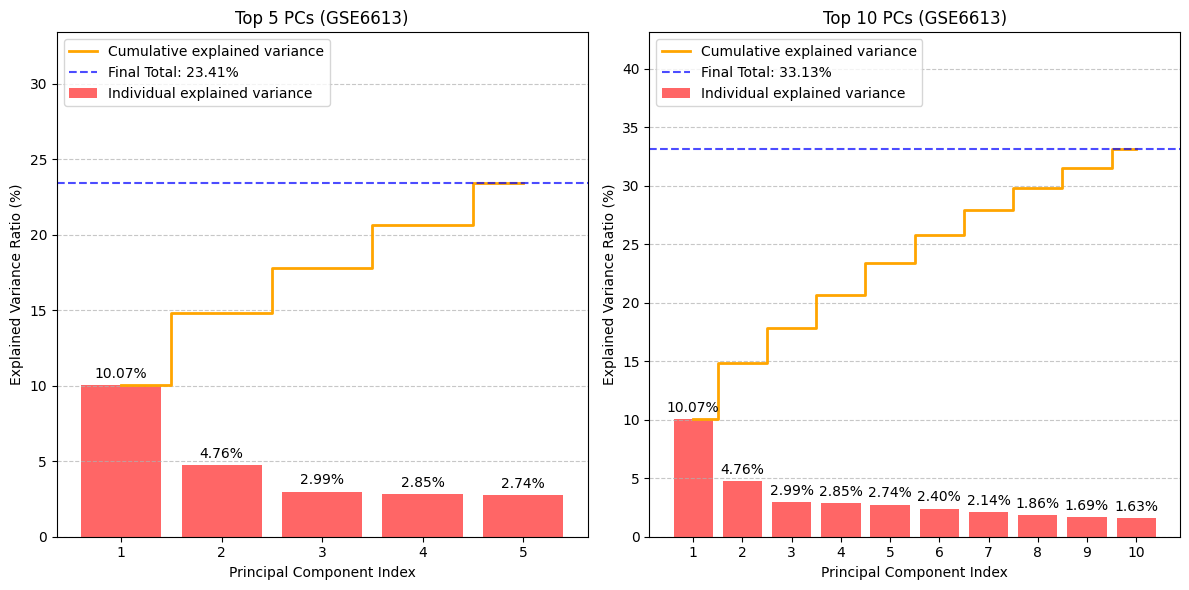

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

variances = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variances) * 100


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

scenarios = [
    (5, axes[0], 'Top 5 PCs'),
    (10, axes[1], 'Top 10 PCs')
]

for n_components, ax, title in scenarios:
    var_slice = variances[:n_components] * 100
    cum_var_slice = cumulative_variance[:n_components]
    x_indices = range(1, n_components + 1)

    bars = ax.bar(x_indices, var_slice, alpha=0.6, align='center',
                  label='Individual explained variance', color='red')
    ax.bar_label(bars, fmt='%.2f%%', padding=3, color='black', fontsize=10)


    ax.step(x_indices, cum_var_slice, where='mid',
            label='Cumulative explained variance', color='orange', linewidth=2)

    final_variance = cum_var_slice[-1]
    ax.axhline(y=final_variance, color='blue', linestyle='--', alpha=0.7,
               label=f'Final Total: {final_variance:.2f}%')

    ax.set_ylabel('Explained Variance Ratio (%)')
    ax.set_xlabel('Principal Component Index')
    ax.set_title(f'{title} (GSE6613)')
    ax.set_xticks(x_indices)


    ax.set_ylim(0, max(cum_var_slice) + 10)

    ax.legend(loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Difference Between the TOP 5 and TOP 10 PC based Gene Selection

The 2 lists for 5 principle components and 10 components are signinficantly different. For the top 20 genes, the maximum cumulative explained variance is $33.13\%$ for the 10 PC. This is significantly low compared to the $95\%$ explained variance that is used to set up the principal component analysis. Even though the first PC explains $10.07\%$ variance of the gene sample counts, this is very low. The followings are the pobable reason for such observation:



*   The first few PC's are assigning higher weihtage to the phenotypical conditions rather than the gene counts.
*   The PC 6-10 may be representative of lower overal variance but capture more subtle biological traits significant for the varying gene counts for different groups.



In [ ]:
from IPython.display import display, HTML


genes_5_pca = set(top_20_gene_5_PCA['Gene_ID'])
genes_10_pca = set(top_20_gene_10_PCA['Gene_ID'])


common_genes = genes_5_pca.intersection(genes_10_pca)

print(f"There are {len(common_genes)} genes common to both lists:\n")
print(", ".join(common_genes))
print("\n" + "="*50 + "\n")


def highlight_overlap(row):
    """
    Checks if the Gene_ID in the current row is in our common_genes set.
    If yes, it highlights the entire row in light green.
    """
    if row['Gene_ID'] in common_genes:
        return ['background-color: lightgreen; color: black'] * len(row)
    else:
        return [''] * len(row)


html_5 = top_20_gene_5_PCA.style.apply(highlight_overlap, axis=1).hide(axis="index").to_html()
html_10 = top_20_gene_10_PCA.style.apply(highlight_overlap, axis=1).hide(axis="index").to_html()


html_layout = f"""
<div style="display: flex; gap: 50px;">
    <div>
        <h4 style="margin-bottom: 10px;">Top 20 Genes using 5 PCs</h4>
        {html_5}
    </div>
    <div>
        <h4 style="margin-bottom: 10px;">Top 20 Genes using 10 PCs</h4>
        {html_10}
    </div>
</div>
"""


display(HTML(html_layout))

There are 4 genes common to both lists:

200063_s_at, 221199_at, 211716_x_at, AFFX-BioDn-5_at




Gene_ID,Weighted_Score
200912_s_at,0.002783
204020_at,0.002721
AFFX-r2-Ec-bioD-3_at,0.002690
200627_at,0.002689
200063_s_at,0.002673
201051_at,0.002657
221199_at,0.002645
200858_s_at,0.002614
211699_x_at,0.002611
217232_x_at,0.002607
